# Recurrent Neural Network - Recap

👋 Welcome to this recap of the RNN unit!

📆 We will be revisiting *Challenge 3 - Predict Weather Temperature*.


🎯 ***Predict one target (`N_TARGETS = 1`)***: 
- 🌡 `T (degC)` = temperature in Celsius degrees


We will introduce two modifications to this challenge:

* (1) 🆕 an `OUTPUT_LENGTH > 1`
    * $ \Leftrightarrow$ we will try to predict <u>***MULTIPLE time steps in the future***</u>
    `HORIZON ≥1`
    

* (2) 🆕 a `GAP >1` between the last seen value in $X$ and the first value $y$ to predict in the future:
    * $ \Leftrightarrow$ we want to <u>***make the predictions a few moments AFTER the last known values***</u> 
    * `GAP = HORIZON - 1`

<hr>

_See this illustration down below_ 👇

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/time_series_horizon.png">

## (0) Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

# Data Visualiation
import matplotlib.pyplot as plt
import seaborn as sns

# System
import os

# Deep Learning
import tensorflow as tf

# Checking data types
from typing import Dict, List, Tuple, Sequence
import string

## (1) 📚 The weather dataset

### (1.1) Loading the dataset

🌦 For this recap, we will re-use the preprocessed weather dataset from the *challenge 3 - Predict Weather Temperature*. 


💾 Load it.

In [2]:
url = "https://wagon-public-datasets.s3.amazonaws.com/deep_learning_datasets/weather_every_three_hours_engineered.csv"
df = pd.read_csv(url).drop(columns = ['Unnamed: 0'])
display(df.tail())
print(f"df.shape = {df.shape}")

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day_sin,Day_cos,Year_sin,Year_cos
23358,1006.23,-6.31,266.37,-8.42,84.90,3.81,3.23,0.57,2.00,3.21,1312.01,-1.279930,-0.013404,-1.839899,-0.019268,0.675590,-0.737277,-0.000268,1.000000
23359,1004.62,-0.71,272.09,-5.97,67.37,5.80,3.91,1.89,2.42,3.89,1282.65,-0.976457,-0.412471,-1.916066,-0.809378,-0.043619,-0.999048,0.001883,0.999998
23360,1003.09,4.97,277.88,-3.04,56.03,8.71,4.88,3.83,3.03,4.86,1254.09,-0.403185,-0.359224,-0.776504,-0.691840,-0.737277,-0.675590,0.004033,0.999992
23361,1002.27,-0.42,272.56,-4.92,71.50,5.92,4.23,1.69,2.63,4.22,1278.14,-0.266024,-0.350473,-0.604599,-0.796530,-0.999048,0.043619,0.006183,0.999981
23362,1001.19,-2.75,270.32,-6.90,72.90,4.99,3.64,1.35,2.26,3.63,1288.02,-0.661501,0.257908,-1.453438,0.566672,-0.675590,0.737277,0.008334,0.999965


df.shape = (23363, 19)


👆 *(Reminders*) This weather dataset is a ***single Time Series*** represented as a DataFrame, i.e. a **2D-array**.
- `df.shape = (n_timesteps, n_features)`
    - `n_timesteps` $= 23$k rows  (_~8 years of weather data, from 2009 to 2016 with records every 3 hours_)
    - `n_features` $= 19$ features composed of:
        - $1$ <font color=green>**target**</font> (we will use the past values of the temperature as a feature)
        - $18$ <font color=orange>**past covariates**</font> (= features which past values are known)
        - $0$ <font color=blue>**future covariates**</font> (= features which future values are known, e.g. public holidays)
    
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/time-series-covariates.png'>    

### (1.2) 🌅 The big picture about dealing with Time Series *(reminder)*

1️⃣ <b>[FOLDS] <u>Cross-Validation in Time Series  </u></b>

Starting from this single Time Series:
- We will create <font color="#c91ac9">**FOLDS**</font>
- <font color=blue>**Train**</font>/<font color="#ff8005">**Evaluate**</font> our LSTM  <font color="#c91ac9">**on each of these different FOLDS**</font> to conclude about <b><u>the robustness of the model</u><b>.
    
_It is very common to create hundreds of folds in Time Series forecasting, in order to cover all types of external conditions: crash market periods, bull markets, atone markets, etc..._

2️⃣ <b>[TRAIN-TEST SPLIT] <u>Holdout method</u></b>

For each <font color="#c91ac9">**FOLD**</font>, we will do a <font color=blue>**TRAIN**</font>-<font color="#ff8005">**TEST**</font> SPLIT to:
* <font color=blue>**fit**</font> the model on the <font color=blue>**train**</font> set 
* <font color="#ff8005">**evaluate**</font> it on the <font color="#ff8005">**test**</font> set

_Always split the train set **chronologically** before the test set!_

<hr> 

👇 The first two steps can be summarized in the following image (here, we illustrated a 4-fold temporal cross-validation):

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/time_series_cross_validation.png" alt="Time Series Cross Validation" width="800">

<hr>

3️⃣ <b>[SEQUENCES] <u>Sampling/Extracting sequences</u></b>


After splitting each fold into a <font color="blue">train</font> set and a <font color="#ff8005">test</font> set, it is time to:
- 🏋 sample lots of <font color="#884dff"><i>sequences</i></font> $\color{blue}{(X_i, y_i)}$ on which the model will be <font color="blue">trained</font>
- 👩🏻‍🏫 sample lots of <font color="#884dff"><i>sequences</i></font> $\color{#ff8005}{(X_i, y_i)}$ on which the model will be <font color="#ff8005">evaluated</font>


<img src="https://bit.ly/3Ri8Vfd" alt="Sequences in each fold" width="500"> 

👉 All these <font color="#884dff"><i>sequences</i></font> in the <font color="blue">train</font> set and the <font color="#ff8005">test</font> set will have a common shape `(input_length, n_features)` $ = (14\times8,19) = (112,19)$.

👉 Each <font color="#884dff"><i>sequence</i></font> has a target, the shape of which will be `(output_length, n_targets)` $ = (7\times8, 1) = (56, 1)$.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/shapes_for_input_sequence_and_ouput_sequence.png" alt="3d arrays time series" width="1200"> 

<hr>

> 🔥 Open this [**infograph**](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/big_picture_temporal_data_handling.png)  side-by-side with the notebook for a visual summary! 🔥

## (2) Adapting the functions from the _"Predict Temperature"_ challenge

### (2.0) Global Variables

🌐 Let's define some ***global variables*** that we will use for our tests everywhere in this notebook:

In [ ]:
# Folds
FOLD_LENGTH = 3*365*8      # each fold will have 3 years of data
FOLD_STRIDE = int(365/2)*8 # sliding each semester

# Temporal Train-Test split
TRAIN_TEST_RATIO = 0.66
N_TRAIN = 6666 # number_of_sequences_train for each fold_train
N_TEST =  3333 # number_of_sequences_test for each fold_test

# Inputs
N_FEATURES = 19
INPUT_LENGTH = 14*8 # - Records every 3 hours x 8 = 24 hours
                    # - During two weeks, which is quite common for weather forecasts

# Outputs
TARGET = ['T (degC)']
TARGET_COLUMN_IDX = 1 # 'T (degC)' corresponds to the second column of the df
N_TARGETS = 1
OUTPUT_LENGTH = N_TARGETS*7*8 # - Predicting one target, the temperature
                              # - for one week with predictions every 3 hours

# Additional parameters
HORIZON = 7*8 # - We are predicting the week after the next week

### (2.1)  🗂 <font color="#c91ac9">FOLDS</font>

🎁 **`get_folds`**

You have already coded this function in *Challenge 3 - Predict Weather Temperature*. <br> _Feel free to ask the teacher any questions if something is still not clear._

In [ ]:
def get_folds(df: pd.DataFrame,
              fold_length: int,
              fold_stride: int) -> List[pd.DataFrame]:
    '''
    This function slides through the Time Series dataframe of shape (n_timesteps, n_features) to create folds
    - of equal `fold_length`
    - using `fold_stride` between each fold

    Returns a list of folds, each as a DataFrame
    '''

    folds = []
    for idx in range(0, len(df), fold_stride):
        # Exits the loop as soon as the last fold index would exceed the last index
        if (idx + fold_length) > len(df):
            break
        fold = df.iloc[idx:idx + fold_length, :]
        folds.append(fold)
    return folds

👉 Let's generate these <font color="#c91ac9">**FOLDS**</font>.

In [5]:
folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

print(f'The function generated {len(folds)} folds.')
print(f'Each fold has a shape equal to {folds[0].shape}.')

The function generated 11 folds.
Each fold has a shape equal to (8760, 19).


🧪 Make sure that the following <font color=green>***assert***</font> doesn't return anything (which means the assertion is correct).

In [6]:
assert(folds[0].shape == (8760, 19))

☝️ This amount of <font color="#c91ac9">**FOLDS**</font> should be enough to cross-validate our model correctly!

### (2.2) ✂️  Temporal <font color=blue>Train</font>/<font color="#ff8005">Test</font> Split

👩🏻‍🏫 Let's <font color="#c91ac9">focus on one fold</font> for the moment, the first one for example.

In [7]:
fold = folds[0]
fold

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day_sin,Day_cos,Year_sin,Year_cos
0,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,7.071068e-01,7.071068e-01,0.011483,0.999934
1,997.71,-9.67,263.66,-10.62,92.7,2.93,2.71,0.21,1.69,2.72,1317.71,-0.041452,0.027960,-0.414519,0.279596,1.000000e+00,4.339955e-12,0.013633,0.999907
2,999.69,-7.66,265.52,-8.84,91.2,3.43,3.13,0.30,1.95,3.13,1310.14,-0.314796,-0.128466,-0.583298,-0.238040,7.071068e-01,-7.071068e-01,0.015783,0.999875
3,1000.30,-6.87,266.27,-8.28,89.6,3.64,3.27,0.38,2.03,3.26,1306.98,-1.834577,-0.141163,-2.622249,-0.201771,6.903299e-12,-1.000000e+00,0.017933,0.999839
4,999.88,-5.69,267.48,-7.00,90.4,3.99,3.61,0.38,2.25,3.61,1300.51,-0.825870,0.828758,-1.327039,1.331679,-7.071068e-01,-7.071068e-01,0.020083,0.999798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,980.34,1.45,276.18,0.03,90.2,6.79,6.12,0.67,3.89,6.24,1240.67,-0.604351,-3.731375,-1.191115,-7.354165,-8.715574e-02,-9.961947e-01,-0.028744,0.999587
8756,983.25,2.23,276.73,0.21,86.4,7.18,6.20,0.98,3.93,6.31,1240.81,-0.432628,-2.126437,-0.849307,-4.174479,-7.660444e-01,-6.427876e-01,-0.026594,0.999646
8757,985.46,1.69,276.00,-0.52,85.2,6.90,5.88,1.02,3.72,5.97,1246.23,-0.626578,-2.513066,-0.977364,-3.919995,-9.961947e-01,8.715574e-02,-0.024445,0.999701
8758,986.63,2.16,276.38,-1.14,78.7,7.14,5.62,1.52,3.55,5.70,1245.68,-0.773266,-3.669409,-1.222791,-5.802558,-6.427876e-01,7.660444e-01,-0.022295,0.999751


☝️ We want to split this fold **chronologically** into:

- a <font color=blue>fold_train</font> dataframe
- a <font color="#ff8005">fold_test</font> dataframe

*Each of these fold_train and fold_test will contain all the data we need to be able to sample many pairs `(Xi, yi)` in a next step!*

#### (2.2.1) 🧑🏻‍🏫 We saw how to do it when forecast `horizon = 1` timestep

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/time_serie_test_split_without_horizon.png" alt="train_test_split_temporal" width="800"> 


#### (2.2.1) 🧑🏻‍🏫 The complexity introduced by the <font color=green>gap</font>

<details>
    <summary>⏸ Let's take a <i>quick break</i> from this weather dataset to understand what is a temporal gap.</summary>

<hr>

🤑 Put yourself in the shoes of a quantitative trader at timesteps $\color{blue}{1}, \color{blue}{2}, \color{blue}{3}, ..., \color{blue}{10}$.

Let's say you are in the <font color=blue>training</font> phase, and you want to stop your training after day `10`:
- You have to wait until day `10` to know the real value $y_{10}$, and compare it with the predicted value $\hat{y}_{10}$ to train the model.
 
Here are the <font color=blue>assumptions about your model</font>:
- It is trained on <font color="#884dff"><i>sequences</i></font> with `INPUT_LENGTH = 3`
- The goal is to predict `OUTPUT_LENGTH = 1` point in the future
- You want to predict this point `HORIZON = 4` days after the last known value.

✅ Imagine that your model was trained and put into production

❓ <u>On which day can you evaluate the live performance of the model for the first time</u> ❓

* You are at day `10`. Hence, the first prediction you can make is for day `10` + `HORIZON` = `14`
* You will have to wait until day `14` to see how good was your prediction!
    * `y_test_first` = day `14`
* You sit IDLE for <font color=green>3</font> days $(11, 12, 13)$
    
</details>    

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/train_test_split_with_horizon.jpg?raw=true" height=500 width=800>

👉 The <font color=green>gap</font> between the <font color=blue>train</font> and the <font color=orange>test</font> set should be equal to `GAP = HORIZON - 1`.

#### (2.2.2) 💻 Adapting the  `train_test_split` function accordingly

💻 ❓ **Question ❓ (Temporal <font color=blue>Train</font>/<font color=orange>Test</font> split)** 

Code the function `train_test_split` down below which:
- <i>(inputs)</i> given 
    - a `fold` (like above), 
    - a `train_test_ratio` (e.g 0.8) 
    - an `input_length` (fixed)
    - 🆕 a `horizon` (fixed)
- <i>(output)</i> returns a tuple (`fold_train`, `fold_test`) of DataFrames

<details>
    <summary><i>Hint</i></summary>
    
Compared with `challenge 3`, how do you manage the `horizon` ?    
        
<details> 

In [ ]:
def train_test_split(fold: pd.DataFrame,
                     train_test_ratio: float,
                     input_length: int,
                     horizon: int) -> Tuple[pd.DataFrame]:
    '''
    Returns a train dataframe and a test dataframe (fold_train, fold_test)
    from which one can sample (X,y) sequences.
    df_train should contain all the timesteps until round(train_test_ratio * len(fold))
    '''
    # $CHALLENGIFY_BEGIN

    # TRAIN SET
    # ======================
    last_train_idx = round(train_test_ratio * len(fold))
    fold_train = fold.iloc[0:last_train_idx, :]

    # TEST SET
    # ======================
    first_test_idx = last_train_idx - input_length
    fold_test = fold.iloc[first_test_idx:, :]

    return (fold_train, fold_test)

    # $CHALLENGIFY_END

💻 ❓ **Question ❓ (Temporal <font color=blue>Train</font>/<font color=orange>Test</font> split for <font color="#c91ac9">one fold </font>)** 

Split the <font color="#c91ac9">fold #0</font>.


<details>
    <summary><i>Reminders</i></summary>

*As a reminder, in  section `(2.0) Global Variables`, we defined*:
- *`TRAIN_TEST_RATIO` = 66%* 
- *`INPUT_LENGTH` = 2 weeks = 112 time steps for each `Xi`, which is quite common in weather forecasting*
- *`HORIZON` = 1 day = 8 time steps*

</details>


In [ ]:
(fold_train, fold_test) = train_test_split(fold,
                                           TRAIN_TEST_RATIO,
                                           INPUT_LENGTH,
                                           HORIZON)

🧪 Check that your shapes and your starting/ending points are correct:

In [10]:
## Double-checking the shapes for the fold_train and fold_test
fold_train.shape == (5782, 19)
fold_test.shape == (3090, 19)

## Double-checking the starting point and the ending point for both folds
assert (fold_train.index.start) == 0
assert (fold_train.index.stop) == 5782
assert (fold_test.index.start) == 5670
assert (fold_test.index.stop) == 8760

### (2.3) 💻 🔢 Create (X, y) sequences

In [11]:
# Inputs
print("##### INPUTS #####")
print(f'- INPUT_LENGTH = {INPUT_LENGTH} timesteps = {int(INPUT_LENGTH/8)} days = {int(INPUT_LENGTH/8/7)} weeks')
print(f'- N_FEATURES = {N_FEATURES}')
# Outputs
print("##### OUTPUTS #####")
print(f'- OUTPUT_LENGTH = {OUTPUT_LENGTH} timesteps = {int(OUTPUT_LENGTH/8)} day(s)')
print(f'- N_TARGETS = {N_TARGETS}')
# Parameters
print("##### PARAMETERS #####")
print(f'- HORIZON = {HORIZON} timesteps = {int(HORIZON/8)} day(s)')
# Train
print("##### TRAIN SET #####")
print(f"- The training fold starts at index {fold_train.index.start} and stops at index {fold_train.index.stop}.")
# Test
print("##### TEST SET #####")
print(f"- The test fold starts at index {fold_test.index.start} and stops at index {fold_test.index.stop}.")

##### INPUTS #####
- INPUT_LENGTH = 112 timesteps = 14 days = 2 weeks
- N_FEATURES = 19
##### OUTPUTS #####
- OUTPUT_LENGTH = 56 timesteps = 7 day(s)
- N_TARGETS = 1
##### PARAMETERS #####
- HORIZON = 56 timesteps = 7 day(s)
##### TRAIN SET #####
- The training fold starts at index 0 and stops at index 5782.
##### TEST SET #####
- The test fold starts at index 5670 and stops at index 8760.


In [ ]:
# New: Scanning  through a fold
STRIDE = 3*8 # sliding every three days, for instance
print(f'STRIDE = {STRIDE} timesteps = {int(STRIDE/8)} day(s)')

STRIDE = 24 timesteps = 3 day(s)


💻 ❓ **Question ❓ (Extracting a <font color="#884dff"><i>sequence</i></font>)** 

Code the function `get_Xi_yi` which extracts a <font color="#884dff"><i>sequence</i></font> from a Time Series: it should take the following arguments:
- `first_index`
- `data` (your 2D-dataframe representing the Time Series)
- `input_length`
- `output_length`
- `horizon`

In [ ]:
def get_Xi_yi(first_index: int,
              fold: pd.DataFrame,
              horizon: int,
              input_length: int,
              output_length: int) -> Tuple[np.ndarray, np.ndarray]:
    '''
    - extracts one sequence from a fold
    - returns a pair (Xi, yi) with:
        * len(Xi) = `input_length` and Xi starting at first_index
        * len(yi) = `output_length`
        * last_Xi and first_yi separated by the gap = horizon -1
    '''

    # $CHALLENGIFY_BEGIN

    Xi_start = first_index
    Xi_last = Xi_start + input_length
    yi_start = Xi_last + horizon - 1
    yi_last = yi_start + output_length

    Xi = fold[Xi_start:Xi_last]
    yi = fold[yi_start:yi_last][TARGET]

    return (Xi, yi)

    # $CHALLENGIFY_END

🧪 Run the following cell to test your function:

In [14]:
## Testing your function get_Xi_yi

first_index = fold.index.start
Xi, yi = get_Xi_yi(first_index=first_index,
                   fold=fold,
                   horizon=HORIZON,
                   input_length=INPUT_LENGTH,
                   output_length=OUTPUT_LENGTH)

assert (Xi.index.start == first_index)
assert (Xi.shape == (INPUT_LENGTH, 19))
assert (yi.index.stop == Xi.index.stop + HORIZON - 1 + OUTPUT_LENGTH)
assert (yi.shape == (OUTPUT_LENGTH, 1))

💻 ❓ **Question ❓ (Creating <font color="#884dff"><i>sequences</i></font>, scanning chronologically through a fold)** 

Code the function `get_X_y` to scan an entire fold and extract sequences.

In [15]:
def get_X_y(fold: pd.DataFrame,
            horizon: int,
            input_length: int,
            output_length: int,
            stride: int,
            shuffle=True) -> Tuple[np.ndarray, np.ndarray]:
    """
    - Uses `data`, a 2D-array with axis=0 for timesteps, and axis=1 for (targets+covariates columns)
    - Returns a Tuple (X,y) of two ndarrays :
        * X.shape = (n_samples, input_length, n_covariates)
        * y.shape =
            (n_samples, output_length, n_targets) if all 3-dimensions are of size > 1
            (n_samples, output_length) if n_targets == 1
            (n_samples, n_targets) if output_length == 1
            (n_samples, ) if both n_targets and lenghts == 1
    - You can shuffle the pairs (Xi,yi) of your fold
    """

    # $CHALLENGIFY_BEGIN
    X = []
    y = []

    # Scanning the fold/data entirely with a certain stride
    for i in range(0, len(fold), stride):
        ## Extracting a sequence starting at index_i
        Xi, yi = get_Xi_yi(first_index=i,
                           fold=fold,
                           horizon=horizon,
                           input_length=input_length,
                           output_length=output_length)
        ## Exits loop as soon as we reach the end of the dataset
        if len(yi) < output_length:
            break
        X.append(Xi)
        y.append(yi)

    X = np.array(X)
    y = np.array(y)
    y = np.squeeze(y)

    if shuffle:
        idx = np.arange(len(X))
        np.random.shuffle(idx)
        X = X[idx]
        y = y[idx]

    return X, y

    # $CHALLENGIFY_END

💻 ❓ **Question ❓ Generate <font color="#884dff"><i>sequences</i></font>** both in the <font color=blue>**train**</font> set and the <font color="#ff8005">**test**</font> set.

In [16]:
X_train, y_train = get_X_y(fold=fold_train,
                           horizon=HORIZON,
                           input_length=INPUT_LENGTH,
                           output_length=OUTPUT_LENGTH,
                           stride=STRIDE)
X_test, y_test = get_X_y(fold=fold_test,
                         horizon=HORIZON,
                         input_length=INPUT_LENGTH,
                         output_length=OUTPUT_LENGTH,
                         stride=STRIDE)

print("Shapes for the training set:")
print(f"X_train.shape = {X_train.shape}, y_train.shape = {y_train.shape}")

print("Shapes for the test set:")
print(f"X_test.shape = {X_test.shape}, y_test.shape = {y_test.shape}")

Shapes for the training set:
X_train.shape = (232, 112, 19), y_train.shape = (232, 56)
Shapes for the test set:
X_test.shape = (120, 112, 19), y_test.shape = (120, 56)


🧪 Test that your shapes are correct. If not, go back to the function to debug it.

In [17]:
## ASSERTS
assert(X_train.shape == (232, INPUT_LENGTH, N_FEATURES))
assert(y_train.shape == (232, OUTPUT_LENGTH))
assert(X_test.shape == (120, INPUT_LENGTH, N_FEATURES))
assert(y_test.shape == (120, OUTPUT_LENGTH))

## (3) 💻 Modelling

### (3.1) 💻 LSTM

💻 ❓ **Question (the LSTM model)** ❓ (<i>Adapting the code from Challenge 3</i>)

We took the architecture of the LSTM model from the previous challenge. The function `init_model` initializes and compiles it.

👉 Now that we are ***predicting multiple steps in the future***, what do you need to change in this function?

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Normalization
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras import regularizers


def init_model(X_train, y_train):

    # 0 - Normalization
    # ======================
    normalizer = Normalization()
    normalizer.adapt(X_train)

    # 1 - RNN architecture
    # ======================
    model = models.Sequential()
    # Normalizing Inputs
    model.add(normalizer)
    # Recurrent Layer
    model.add(layers.LSTM(units=64, activation='tanh', return_sequences=False,
                          recurrent_dropout=0.5, dropout=0.5))
    # Hidden Dense Layer that we are regularizing
    reg_l2 = regularizers.L2(0.5)
    model.add(layers.Dense(32, activation="relu", kernel_regularizer = reg_l2))
    model.add(layers.Dropout(rate=0.5))

    # Predictive Dense Layer
    ### model.add(layers.Dense(1, activation='linear'))
    ### QUESTION: HOW DO YOU CHANGE THIS PART FOR MULTIPLE STEPS ?
    # $CHALLENGIFY_BEGIN
    output_length = y_train.shape[1]
    model.add(layers.Dense(output_length, activation='linear'))
    # $CHALLENGIFY_END

    # 2 - Compiler
    # ======================
    initial_learning_rate = 0.01

    lr_schedule = ExponentialDecay(initial_learning_rate, decay_steps=1000, decay_rate=0.5)

    adam = optimizers.Adam(learning_rate=lr_schedule)
    model.compile(loss='mse', optimizer=adam, metrics=["mae"])

    return model


🎁 **Training**: We can re-use the function `fit_model` from the last challenge to <font color=blue>train</font> the model.

In [19]:
from tensorflow.keras.callbacks import EarlyStopping


def fit_model(model: tf.keras.Model, verbose=1) -> Tuple[tf.keras.Model, dict]:

    es = EarlyStopping(monitor="val_loss",
                       patience=10,
                       mode="min",
                       restore_best_weights=True)

    history = model.fit(X_train,
                        y_train,
                        validation_split=0.3,
                        shuffle=False,
                        batch_size=32,
                        epochs=200,
                        callbacks=[es],
                        verbose=verbose)

    return model, history

🎁 **Visualizing performance:** Feel free to use the `plot_history` function to visualize how your model learned.

In [ ]:
def plot_history(history):

    fig, ax = plt.subplots(1,2, figsize=(20,7))
    # --- LOSS: MSE ---
    ax[0].plot(history.history['loss'])
    ax[0].plot(history.history['val_loss'])
    ax[0].set_title('MSE')
    ax[0].set_ylabel('Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].legend(['Train', 'Validation'], loc='best')
    ax[0].grid(axis="x",linewidth=0.5)
    ax[0].grid(axis="y",linewidth=0.5)

    # --- METRICS:MAE ---

    ax[1].plot(history.history['mae'])
    ax[1].plot(history.history['val_mae'])
    ax[1].set_title('MAE')
    ax[1].set_ylabel('MAE')
    ax[1].set_xlabel('Epoch')
    ax[1].legend(['Train', 'Validation'], loc='best')
    ax[1].grid(axis="x",linewidth=0.5)
    ax[1].grid(axis="y",linewidth=0.5)

    return ax

💻 ❓ **Questions ❓ (Training and Evaluating the LSTM model)**

Using your functions `init_model` and `fit_model`:
1. **Initialize** your model
2. <font color=blue>**Train**</font> it and observe the performances on the train set and the validation set
3. <font color=orange>**Evaluate**</font> it on the test set

_Feel free to apply regularization techniques in the architecture if the model overfits._

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (232, 112, 19)         │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39 (160.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 39 (160.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 43.7824 - mae: 5.0947 
--------------------------------------------------
The LSTM MAE on the test set is equal to 5.09 Celsius degrees
CPU times: user 8.19 s, sys: 1.25 s, total: 9.43 s
Wall time: 6.6 s


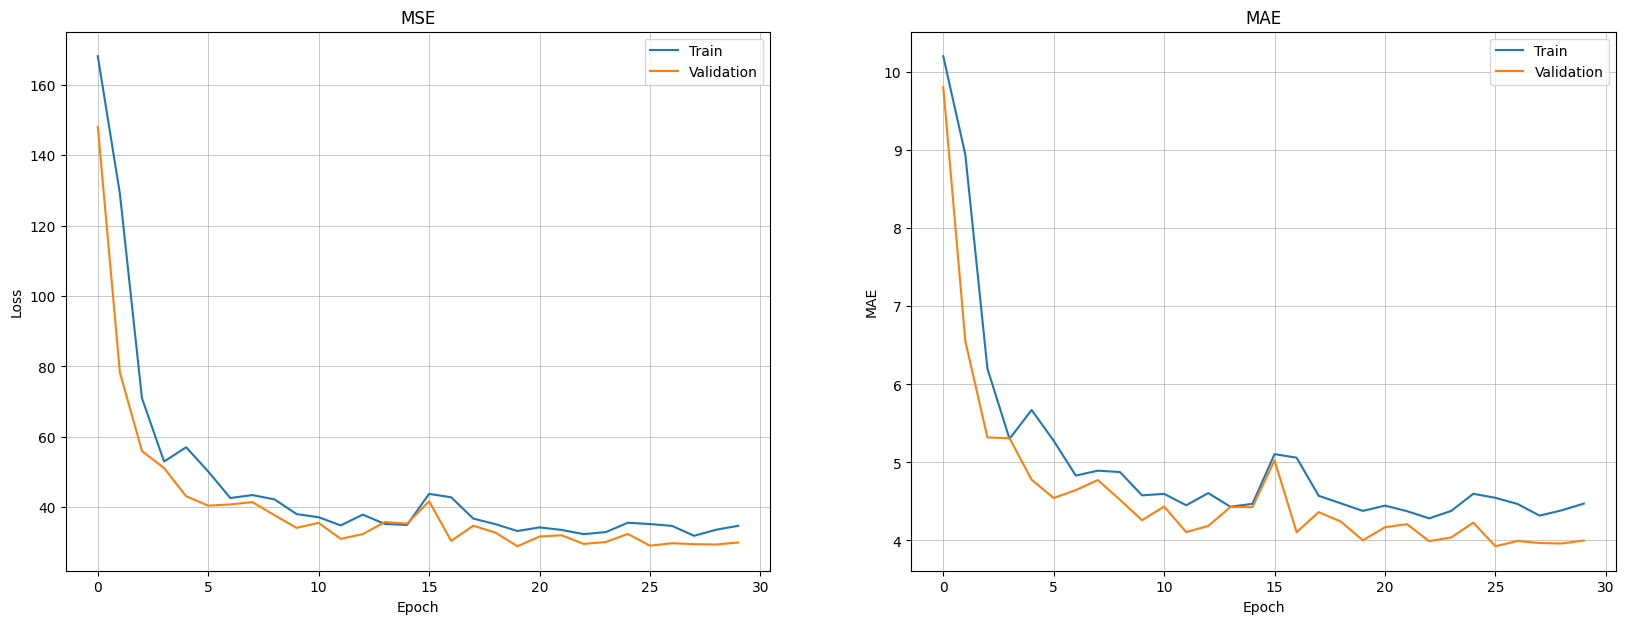

In [21]:
%%time
# 1 - Initialising the RNN model
# ==================================== #
model = init_model(X_train, y_train)
model.summary()

# 2 - Training
# ====================================
model, history = fit_model(model, verbose=0)
plot_history(history);

# 3 - Evaluation
# ====================================
res = model.evaluate(X_test, y_test)
print("-"*50)
print(f"The LSTM MAE on the test set is equal to {round(res[1],2)} Celsius degrees")

### (3.2) 🎁 Baseline with a horizon

👉 (*Reminder*) ***In Time Series, an "intuitive" baseline model is to repeat the last seen value as (a) prediction(s) for the future value(s)*** you want to forecast, as illustrated down below!

<img src = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/last_seen_value_with_horizon.png" width = 600 height = 300>

🎁 **The Last Seen Value Baseline Model** 

Let's go together through the function `last_seen_value_baseline` which:
- (_input_) takes a pair $(X, y)$ 
- (_output_) computes the MAE of the `"repeated last seen value"`  baseline model

In [ ]:
TARGET_COLUMN_IDX = 1 # the second column of each fold corresponds to the temperature

def last_seen_value_baseline(X, y):

    # How many values do you want to predict in the future ?
    output_length = y.shape[-1]

    # For each sequence, let's consider the last seen value
    # and only the temperature column
    last_seen_values = X[:,-1, TARGET_COLUMN_IDX].reshape(-1,1)

    # We need to duplicate these values as many times as output_length
    # The author of this notebook did not know how to do it, so they searched on Stackoverflow
    # and found this nice np.repeat in Numpy, which is self-explanatory
    repeated = np.repeat(last_seen_values, axis = 1, repeats = output_length)

    return np.mean(np.abs(y_test - repeated))

🕵🏻‍♀️ What is the performance of the "last seen value baseline model" on the <font color=orange>**test**</font> set?

In [23]:
# 1 - Evaluation of the Baseline Model
# ====================================
mae_baseline = last_seen_value_baseline(X_test, y_test)
print(f"- The Baseline MAE on the test set is equal to {round(mae_baseline,2)} Celsius degrees")

# 4 - Comparison with the LSTM model
# ====================================
print(f"- The LSTM MAE on the test set is equal to {round(res[1],2)} Celsius degrees")
print(f"👉 Improvement/decrease of the LSTM model over the baseline (on this fold for the test set) = : {round((1 - (res[1]/mae_baseline))*100,2)} % 👈")

- The Baseline MAE on the test set is equal to 5.85 Celsius degrees
- The LSTM MAE on the test set is equal to 5.09 Celsius degrees
👉 Improvement/decrease of the LSTM model over the baseline (on this fold for the test set) = : 13.04 % 👈


<u><b><i>Warnings:</i></b></u>

* Do you remember the challenge `Predict weather temperature` where we were trying to predict the temperature in three hours, i.e. ***the next data point***? We were able to improve the MAE by 30-40% on the LSTM vs. the baseline for every fold, and the MAE was more or less between 1 and 2 degrees Celsius.

* <font color=red>***The more data points in the future we try to predict, the higher your MAE will be!***</font>

* *It is more and more frequent to see a 4/5 Celsius degrees - difference between the real temperature in seven days and the currently predicted value!*

### (3.3) 💻 Cross-Validation

ℹ️ Reminders of the global variables in this notebook:

In [ ]:
# Folds
print('##### FOLDS ##### ')
print(f'- FOLD_LENGTH = {FOLD_LENGTH} timesteps = {3} years x {365} days x {8} records per day')
print(f'- FOLD_STRIDE = {FOLD_STRIDE} timesteps = {(365/2)} days x {8} records per day = sliding each semester')

# Chronological Train Test Split
print('##### TRAIN TEST SPLIT #####')
print(f'- TRAIN_TEST_RATIO = {TRAIN_TEST_RATIO}')
print(f'- N_TRAIN = {N_TRAIN}')
print(f'- N_TEST = {N_TEST}')

# Inputs
print('##### INPUTS #####')
print(f'- INPUT_LENGTH = {INPUT_LENGTH} timesteps = {int(INPUT_LENGTH/8)} days x {8} records per day = {int(INPUT_LENGTH/8/7)} weeks')
print(f'- N_FEATURES = {N_FEATURES}')

# Outputs
print('##### OUTPUTS #####')
print(f'- OUTPUT_LENGTH = {OUTPUT_LENGTH} timesteps = {int(OUTPUT_LENGTH/8)} day(s) x {8} records per day')
print(f"- Trying to predict:{TARGET}")
print(f'- N_TARGETS = {N_TARGETS}')

# Parameters
print('##### PARAMETERS #####')
print(f'- HORIZON = {HORIZON} timesteps = {int(HORIZON/8)} day(s) x {8} records per day')


##### FOLDS ##### 
- FOLD_LENGTH = 8760 timesteps = 3 years x 365 days x 8 records per day
- FOLD_STRIDE = 1456 timesteps = 182.5 days x 8 records per day = sliding each semester
##### TRAIN TEST SPLIT #####
- TRAIN_TEST_RATIO = 0.66
- N_TRAIN = 6666
- N_TEST = 3333
##### INPUTS #####
- INPUT_LENGTH = 112 timesteps = 14 days x 8 records per day = 2 weeks
- N_FEATURES = 19
##### OUTPUTS #####
- OUTPUT_LENGTH = 56 timesteps = 7 day(s) x 8 records per day
- Trying to predict:['T (degC)']
- N_TARGETS = 1
##### PARAMETERS #####
- HORIZON = 56 timesteps = 7 day(s) x 8 records per day


In [25]:
# Remember how many folds do we have ?
folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)
print(f"WARNING, we have {len(folds)} FOLDS, it may take a long time to run...!")

WARNING, we have 11 FOLDS, it may take a long time to run...!


🎁 **Cross-validating the LSTM and the baseline** 

_Let's go together through the following code_ 👇

In [26]:
# Let's reload the dataset, just in case
url = "https://wagon-public-datasets.s3.amazonaws.com/deep_learning_datasets/weather_every_three_hours_engineered.csv"
df = pd.read_csv(url).drop(columns = ['Unnamed: 0'])

In [ ]:
list_of_mae_baseline_model = []
list_of_mae_recurrent_model = []

# 1 - Creating FOLDS
# =======================================================

folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

for fold_id, fold in enumerate(folds):

    # 2 - CHRONOLOGICAL TRAIN TEST SPLIT of the current FOLD
    # =======================================================

    (fold_train, fold_test) = train_test_split(fold = fold,
                                               train_test_ratio = TRAIN_TEST_RATIO,
                                               input_length = INPUT_LENGTH,
                                               horizon = HORIZON)

    # 3 - Scanninng fold_train and fold_test for SEQUENCES
    # =======================================================

    X_train, y_train = get_X_y(fold = fold_train,
                               horizon = HORIZON,
                               input_length = INPUT_LENGTH,
                               output_length = OUTPUT_LENGTH,
                               stride = STRIDE)

    X_test, y_test = get_X_y(fold_test,
                             horizon = HORIZON,
                             input_length = INPUT_LENGTH,
                             output_length = OUTPUT_LENGTH,
                             stride = STRIDE)

    # 4.1 - Baseline Model
    # =======================================================
    mae_baseline = last_seen_value_baseline(X_test, y_test)
    list_of_mae_baseline_model.append(mae_baseline)

    print("-"*50)
    print(f"MAE baseline fold n°{fold_id} = {round(mae_baseline, 2)}")


    # 4.2 - LSTM Model
    # =======================================================

    # Initializing the LSTM Model
    model = init_model(X_train, y_train)
    # Training
    model, history = fit_model(model, verbose=0)
    # Evaluation
    res = model.evaluate(X_test, y_test, verbose = 0)
    mae_lstm = res[1]

    list_of_mae_recurrent_model.append(mae_lstm)

    print(f"MAE LSTM fold n°{fold_id} = {round(mae_lstm, 2)}")

    # 4.3 - Comparison LSTM vs Baseline for the current fold
    # =======================================================
    print(f"🏋🏽‍♂️ Improvement/Decrease vs. Baseline: {round((1 - (mae_lstm/mae_baseline))*100,2)} % \n")

--------------------------------------------------
MAE baseline fold n°0 = 5.85
MAE LSTM fold n°0 = 5.04
🏋🏽‍♂️ Improvement/Decrease vs. Baseline: 13.95 % 

--------------------------------------------------
MAE baseline fold n°1 = 5.73
MAE LSTM fold n°1 = 5.17
🏋🏽‍♂️ Improvement/Decrease vs. Baseline: 9.73 % 

--------------------------------------------------
MAE baseline fold n°2 = 6.1
MAE LSTM fold n°2 = 5.16
🏋🏽‍♂️ Improvement/Decrease vs. Baseline: 15.32 % 

--------------------------------------------------
MAE baseline fold n°3 = 5.76
MAE LSTM fold n°3 = 4.9
🏋🏽‍♂️ Improvement/Decrease vs. Baseline: 15.04 % 

--------------------------------------------------
MAE baseline fold n°4 = 5.49
MAE LSTM fold n°4 = 4.88
🏋🏽‍♂️ Improvement/Decrease vs. Baseline: 11.13 % 

--------------------------------------------------
MAE baseline fold n°5 = 5.27
MAE LSTM fold n°5 = 5.06
🏋🏽‍♂️ Improvement/Decrease vs. Baseline: 3.98 % 

--------------------------------------------------
MAE baseline fold

In [ ]:
cv_mae_baseline = np.mean(list_of_mae_baseline_model)
cv_mae_lstm = np.mean(list_of_mae_recurrent_model)

print("-"*50)
print(f"Average MAE baseline = {round(cv_mae_baseline, 2)}")
print(f"Average LSTM baseline = {round(cv_mae_lstm, 2)}")
print(f"🏋🏽‍♂️ Improvement/Decrease vs. Baseline: {round((1 - (cv_mae_lstm/cv_mae_baseline))*100,2)} % \n")

--------------------------------------------------
Average MAE baseline = 5.63
Average LSTM baseline = 4.9
🏋🏽‍♂️ Improvement/Decrease vs. Baseline: 12.94 % 



🏁 Congratulations for finishing this day about RNN!

🃏 Don't forget your flashcards!

## 🏁 Final words

* 🤯 Predicting the temperature for 7 days every 3 hours, after waiting for 7 days, is not an easy task at all.
    - The LSTM model did not perform well on some folds
    - 5 degrees is a high MAE, one should take into account how "volatile" the temperature has been over the last two decades...

<hr>


* 🕵🏻 We may need weather data from other cities.
* 🤔 If you plan to use Recurrent Neural Networks during your project, ask your Batch Mananger and the most experienced teachers and TAs if about the quality of your data and the feasibility of your projects.
* 😇 Keep the morale high, RNNs are complex networks but they are pretty useful for _Natural Language Processing_. Stay tuned!

<hr>

#### Bonus: what is the main difficulty when trying to regress multiple targets in RNN ? 

- *Optional question only for very advanced students!*
- *For 99% of the students: read it later :) it's time to go home!*

🕵🏻‍♂️ We could have also tried to predict to <b>predict multiple targets</b>... which would have complexified the problem! 

<hr>

<details>
        <summary><i>Why, you ask ?</i></summary>
    
Imagine that you want to predict `N_TARGETS = 3` for 7 days in the future `OUTPUT_LENGTH = 7 x 8  = 56 timesteps`
    
- 🌡 `T (degC)` = temperature in Celsius degrees
- ♒️ `p (mbar)` = atmospheric air pressure in millibars
- 💦 `rh (%)` = relative humidity expressed as a percent 
    
👍 The predictive Dense Layer in your architecture will contain `3 x (7 x 8) = 168` neurons, that is totally doable. 
    
☢️ However when you compile the model, you will choose `metrics = ['mae']` and will evaluate your model on a metric which doesn't make any sense because you are mixing absolute errors of temperature, air pressure and relative humidity... ***You should create a custom metrics which computes one mae per target*** for example. It is possible  but for this recap, we will stay focused on one feature. Feel free to think about this question if your data science project needs it! </details>        